In [4]:
import pandas as pd

df = pd.read_csv("skladi_with_price_and_distance.csv", index_col=0)
df.dropna(subset=["price"], inplace=True)

TRIPS_PER_MONTH = 4
AVG_SPEED_KMH = 30
LOADER_HOURS = 1

TARIFFS = [
    (0.5, 1480, 1125),
    (1.0, 2980, 1125),
    (2.0, 4030, 2000),
    (3.0, 4630, 3000),
]


def trip_cost(hours):
    for min_h, base, loader_rate in TARIFFS:
        if hours <= min_h:
            return base + LOADER_HOURS * loader_rate
    min_h, base, loader_rate = TARIFFS[-1]
    return base + LOADER_HOURS * loader_rate


df["hours"] = df["distance_km"] * 2 / AVG_SPEED_KMH
df["trip_cost"] = df["hours"].apply(trip_cost)

df["storage_monthly"] = df["price"] * 5
df["delivery_monthly"] = df["trip_cost"] * TRIPS_PER_MONTH
df["total_monthly"] = df["storage_monthly"] + df["delivery_monthly"]

df.sort_values("total_monthly").head()

,id,price,latitude,longitude,distance_km,hours,trip_cost,storage_monthly,delivery_monthly,total_monthly
23,107448,381.0,55.648926,37.630894,4.331,0.288733,2605,1905.0,10420,12325.0
3,117826,487.0,55.730332,37.707723,4.440,0.296000,2605,2435.0,10420,12855.0
8,114430,508.0,55.744630,37.786240,3.407,0.227133,2605,2540.0,10420,12960.0
27,114745,700.0,55.622301,37.634004,5.769,0.384600,2605,3500.0,10420,13920.0
22,121855,710.0,55.864987,37.581679,2.756,0.183733,2605,3550.0,10420,13970.0


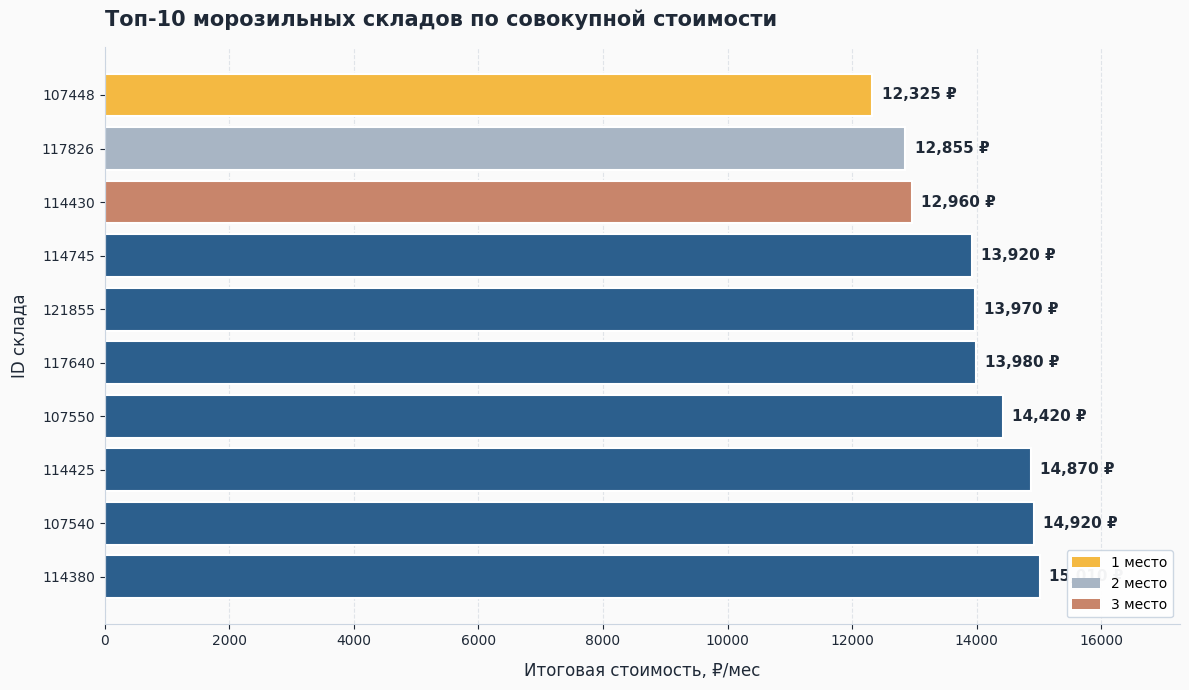

In [5]:
import matplotlib.pyplot as plt
import numpy as np

result = df.sort_values("total_monthly").reset_index(drop=True)
top10 = result.head(10)

PRIMARY = "#2C5F8D"
GOLD = "#F4B942"
SILVER = "#A8B5C4"
BRONZE = "#C8856B"
BG = "#FAFAFA"
TEXT = "#1F2937"

colors = [GOLD, SILVER, BRONZE] + [PRIMARY] * (len(top10) - 3)

fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.barh(
    top10["id"].astype(str),
    top10["total_monthly"],
    color=colors,
    edgecolor="white",
    linewidth=1.5,
)
ax.invert_yaxis()

for bar, value in zip(bars, top10["total_monthly"]):
    ax.text(
        value + 150,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f} ₽",
        va="center",
        fontsize=11,
        color=TEXT,
        fontweight="bold",
    )

ax.set_xlabel("Итоговая стоимость, ₽/мес", fontsize=12, color=TEXT, labelpad=10)
ax.set_ylabel("ID склада", fontsize=12, color=TEXT, labelpad=10)
ax.set_title(
    "Топ-10 морозильных складов по совокупной стоимости",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    pad=15,
    loc="left",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")
ax.spines["bottom"].set_color("#CBD5E1")
ax.tick_params(colors=TEXT, labelsize=10)
ax.grid(axis="x", alpha=0.25, linestyle="--", color="#94A3B8")
ax.set_axisbelow(True)
ax.set_xlim(0, top10["total_monthly"].max() * 1.15)

legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=GOLD, label="1 место"),
    plt.Rectangle((0, 0), 1, 1, fc=SILVER, label="2 место"),
    plt.Rectangle((0, 0), 1, 1, fc=BRONZE, label="3 место"),
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    framealpha=0.95,
    edgecolor="#CBD5E1",
    fontsize=10,
)

plt.tight_layout()
plt.show()

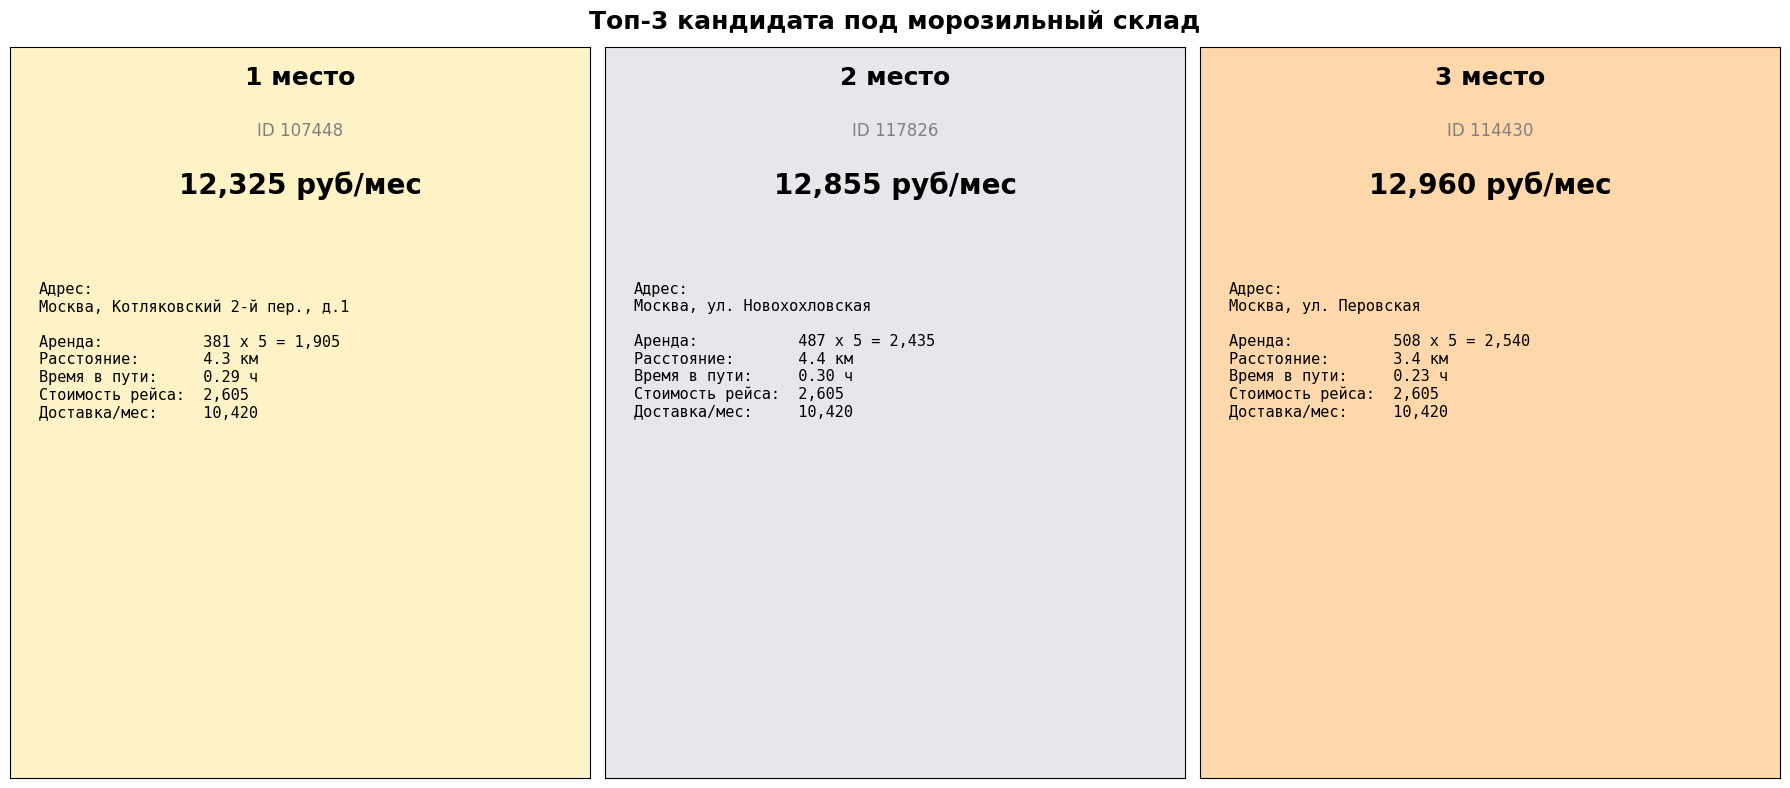

In [7]:
result = df.sort_values("total_monthly").reset_index(drop=True)
top3 = result.head(3)

addresses = [
    "Москва, Котляковский 2-й пер., д.1",
    "Москва, ул. Новохохловская",
    "Москва, ул. Перовская",
]

colors = ["#FEF3C7", "#E5E7EB", "#FED7AA"]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i in range(3):
    ax = axes[i]
    row = top3.iloc[i]

    ax.set_facecolor(colors[i])
    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(0.5, 0.95, f"{i + 1} место", ha="center", fontsize=18, fontweight="bold")
    ax.text(0.5, 0.88, f"ID {int(row['id'])}", ha="center", fontsize=12, color="gray")
    ax.text(
        0.5,
        0.80,
        f"{row['total_monthly']:,.0f} руб/мес",
        ha="center",
        fontsize=20,
        fontweight="bold",
    )

    text = (
        f"Адрес:\n{addresses[i]}\n\n"
        f"Аренда:           {row['price']:.0f} x 5 = {row['storage_monthly']:,.0f}\n"
        f"Расстояние:       {row['distance_km']:.1f} км\n"
        f"Время в пути:     {row['hours']:.2f} ч\n"
        f"Стоимость рейса:  {row['trip_cost']:,.0f}\n"
        f"Доставка/мес:     {row['delivery_monthly']:,.0f}"
    )

    ax.text(0.05, 0.68, text, fontsize=11, verticalalignment="top", family="monospace")

plt.suptitle("Топ-3 кандидата под морозильный склад", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

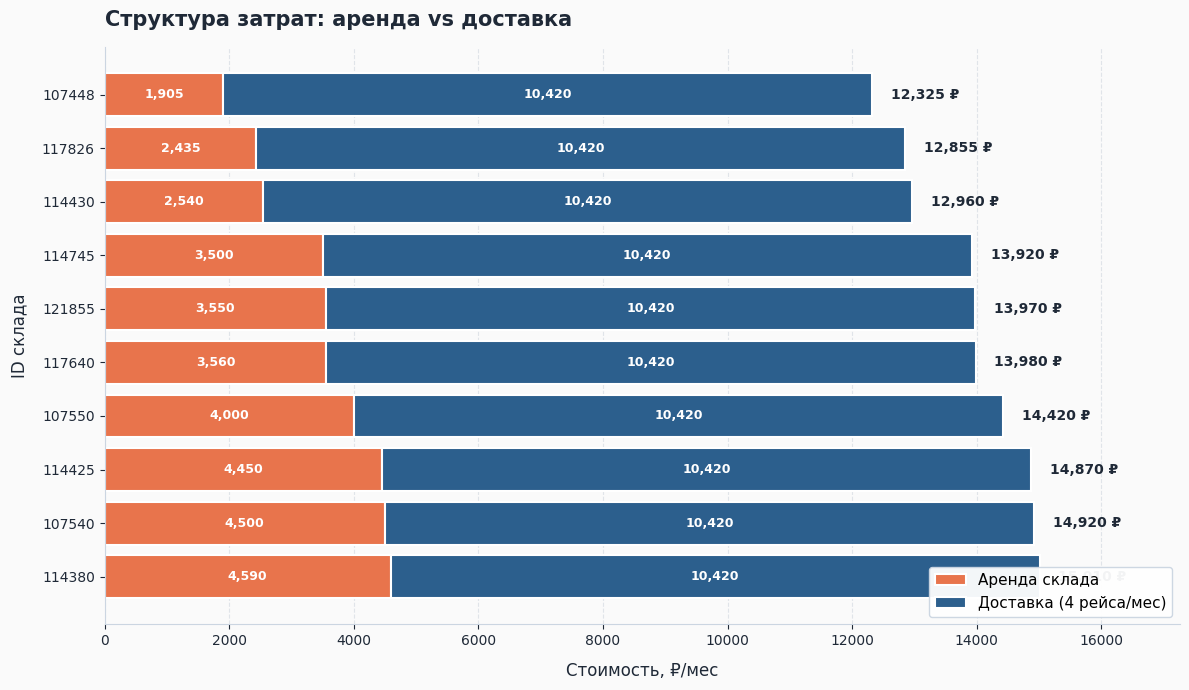

In [8]:
result = df.sort_values("total_monthly").reset_index(drop=True)
top10 = result.head(10)

RENT_COLOR = "#E8744C"
DELIVERY_COLOR = "#2C5F8D"
BG = "#FAFAFA"
TEXT = "#1F2937"

fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG)
ax.set_facecolor(BG)

ids = top10["id"].astype(str)
bars1 = ax.barh(
    ids,
    top10["storage_monthly"],
    color=RENT_COLOR,
    edgecolor="white",
    linewidth=1.5,
    label="Аренда склада",
)
bars2 = ax.barh(
    ids,
    top10["delivery_monthly"],
    left=top10["storage_monthly"],
    color=DELIVERY_COLOR,
    edgecolor="white",
    linewidth=1.5,
    label="Доставка (4 рейса/мес)",
)
ax.invert_yaxis()

for i, (rent, deliv, total) in enumerate(
    zip(top10["storage_monthly"], top10["delivery_monthly"], top10["total_monthly"])
):
    if rent > total * 0.08:
        ax.text(
            rent / 2,
            i,
            f"{rent:,.0f}",
            va="center",
            ha="center",
            color="white",
            fontsize=9,
            fontweight="bold",
        )
    ax.text(
        rent + deliv / 2,
        i,
        f"{deliv:,.0f}",
        va="center",
        ha="center",
        color="white",
        fontsize=9,
        fontweight="bold",
    )
    ax.text(
        total + 300,
        i,
        f"{total:,.0f} ₽",
        va="center",
        fontsize=10,
        color=TEXT,
        fontweight="bold",
    )

ax.set_xlabel("Стоимость, ₽/мес", fontsize=12, color=TEXT, labelpad=10)
ax.set_ylabel("ID склада", fontsize=12, color=TEXT, labelpad=10)
ax.set_title(
    "Структура затрат: аренда vs доставка",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    pad=15,
    loc="left",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")
ax.spines["bottom"].set_color("#CBD5E1")
ax.tick_params(colors=TEXT, labelsize=10)
ax.grid(axis="x", alpha=0.25, linestyle="--", color="#94A3B8")
ax.set_axisbelow(True)
ax.set_xlim(0, top10["total_monthly"].max() * 1.15)

ax.legend(
    loc="lower right", frameon=True, framealpha=0.95, edgecolor="#CBD5E1", fontsize=11
)

plt.tight_layout()
plt.show()

In [12]:
import folium
from IPython.display import display, HTML

result = df.sort_values("total_monthly").reset_index(drop=True)
top3 = result.head(3)

addresses = [
    "Москва, Котляковский 2-й пер., д.1",
    "Москва, ул. Новохохловская",
    "Москва, ул. Перовская",
]

colors = ["#F4B942", "#94A3B8", "#C8856B"]
labels = ["1 место", "2 место", "3 место"]

m = folium.Map(location=[55.75, 37.62], zoom_start=10, tiles="OpenStreetMap")

for i in range(3):
    row = top3.iloc[i]
    popup_html = (
        f"<b>{labels[i]}</b><br>"
        f"ID {int(row['id'])}<br>"
        f"{addresses[i]}<br>"
        f"<b>{row['total_monthly']:,.0f} ₽/мес</b><br>"
        f"Аренда: {row['storage_monthly']:,.0f} ₽<br>"
        f"Доставка: {row['delivery_monthly']:,.0f} ₽<br>"
        f"Расстояние: {row['distance_km']:.1f} км"
    )

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=14,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{labels[i]}: {row['total_monthly']:,.0f} ₽/мес",
        color="black",
        weight=2,
        fill=True,
        fill_color=colors[i],
        fill_opacity=0.9,
    ).add_to(m)

display(HTML(m._repr_html_()))